# Eedi - Mining Misconceptions in Mathematics

### Predicting Affinity Between Misconceptions and Incorrect Answers in Multiple-Choice Questions

This notebook contains a deep learning solution for the [Kaggle Competition: Eedi - Mining Misconceptions in Mathematics](https://www.kaggle.com/competitions/eedi-mining-misconceptions-in-mathematics/).

Github Repository: https://github.com/itsmostafa/mining-misconceptions-final-project

---

## 1. Deep Learning Problem Description

### 1.1 Competition Overview

In educational assessments, multiple-choice questions are designed with **distractors** (incorrect answer choices) that target specific **misconceptions** students may have. When a student selects an incorrect answer, it often reveals a particular misunderstanding of the underlying concept.

**Goal**: Develop an NLP model to predict the affinity between misconceptions and incorrect answers (distractors) in multiple-choice mathematics questions. This solution will suggest candidate misconceptions for distractors, making it easier for expert human teachers to tag distractors with misconceptions.

### 1.2 Problem Framing as a Deep Learning Task

This problem can be framed as a **semantic text retrieval/ranking problem**:

- **Query**: A combination of question context (question text, subject, construct) and the incorrect answer
- **Candidates**: All 2,592 possible misconception descriptions
- **Task**: Rank misconceptions by relevance to each distractor

#### Architecture: Bi-Encoder with Contrastive Learning

I use a **Sentence-BERT bi-encoder architecture**:

```
Query Encoder:  [Question + Subject + Construct + Wrong Answer] → Embedding (384d)
Misconception Encoder: [Misconception Description] → Embedding (384d)
Similarity: cosine_similarity(query_embedding, misconception_embedding)
```

**Why this approach?**
1. **Efficient inference**: Encode all misconceptions once, then retrieve by similarity
2. **Scalable**: Works well with 2,592 candidates
3. **Proven**: Sentence-BERT excels at semantic similarity tasks

#### Training: Contrastive Learning with Multiple Negatives Ranking Loss

- Uses in-batch negatives for efficient training
- Pushes positive pairs (query, correct misconception) closer together
- Pushes negative pairs (query, incorrect misconceptions) further apart

### 1.3 Evaluation Metric: MAP@25

The competition uses **Mean Average Precision @ 25 (MAP@25)**:

$$MAP@25 = \frac{1}{N} \sum_{i=1}^{N} AP@25_i$$

Where:
- $N$ = total number of query-answer pairs
- $AP@25$ = Average Precision at rank 25 for a single query

For a single correct answer at position $k$ in the ranked list:
$$AP@25 = \frac{1}{k} \text{ if } k \leq 25, \text{ else } 0$$

This metric rewards models that rank the correct misconception higher in the list of 25 predictions.

---

## 2. EDA Procedure

### 2.1 Setup and Data Loading

In [121]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [122]:
# Load datasets
train_df = pd.read_csv('data/train.csv')
misconceptions_df = pd.read_csv('data/misconception_mapping.csv')
test_df = pd.read_csv('data/test.csv')
sample_submission = pd.read_csv('data/sample_submission.csv')

print("Datasets loaded:")
print(f"  - Training data: {len(train_df):,} questions")
print(f"  - Misconceptions: {len(misconceptions_df):,} unique misconceptions")
print(f"  - Test data: {len(test_df):,} questions")
print(f"  - Sample submission: {len(sample_submission):,} rows")

Datasets loaded:
  - Training data: 1,869 questions
  - Misconceptions: 2,587 unique misconceptions
  - Test data: 3 questions
  - Sample submission: 9 rows


### 2.2 Basic Statistics and Data Structure

In [123]:
# Display training data structure
print("Training Data Columns:")
print(train_df.columns.tolist())
print("\nFirst few rows:")
train_df.head(3)

Training Data Columns:
['QuestionId', 'ConstructId', 'ConstructName', 'SubjectId', 'SubjectName', 'CorrectAnswer', 'QuestionText', 'AnswerAText', 'AnswerBText', 'AnswerCText', 'AnswerDText', 'MisconceptionAId', 'MisconceptionBId', 'MisconceptionCId', 'MisconceptionDId']

First few rows:


,QuestionId,ConstructId,ConstructName,SubjectId,SubjectName,CorrectAnswer,QuestionText,AnswerAText,AnswerBText,AnswerCText,AnswerDText,MisconceptionAId,MisconceptionBId,MisconceptionCId,MisconceptionDId
0,0,856,Use the order of operations to carry out calcu...,33,BIDMAS,A,\[\n3 \times 2+4-5\n\]\nWhere do the brackets ...,\( 3 \times(2+4)-5 \),\( 3 \times 2+(4-5) \),\( 3 \times(2+4-5) \),Does not need brackets,NaN,NaN,NaN,1672.0
1,1,1612,Simplify an algebraic fraction by factorising ...,1077,Simplifying Algebraic Fractions,D,"Simplify the following, if possible: \( \frac{...",\( m+1 \),\( m+2 \),\( m-1 \),Does not simplify,2142.0,143.0,2142.0,NaN
2,2,2774,Calculate the range from a list of data,339,Range and Interquartile Range from a List of Data,B,Tom and Katie are discussing the \( 5 \) plant...,Only\nTom,Only\nKatie,Both Tom and Katie,Neither is correct,1287.0,NaN,1287.0,1073.0


In [124]:
# Display misconception mapping structure
print("Misconception Mapping:")
misconceptions_df.head(10)

Misconception Mapping:


,MisconceptionId,MisconceptionName
0,0,Does not know that angles in a triangle sum to...
1,1,Uses dividing fractions method for multiplying...
2,2,Believes there are 100 degrees in a full turn
3,3,Thinks a quadratic without a non variable term...
4,4,Believes addition of terms and powers of terms...
5,5,"When measuring a reflex angle, gives the acute..."
6,6,Can identify the multiplier used to form an eq...
7,7,Believes gradient = change in y
8,8,Student thinks that any two angles along a str...
9,9,Thinks there are 180 degrees in a full turn


In [125]:
# Data types and info
print("Training Data Info:")
train_df.info()

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1869 entries, 0 to 1868
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   QuestionId        1869 non-null   int64  
 1   ConstructId       1869 non-null   int64  
 2   ConstructName     1869 non-null   object 
 3   SubjectId         1869 non-null   int64  
 4   SubjectName       1869 non-null   object 
 5   CorrectAnswer     1869 non-null   object 
 6   QuestionText      1869 non-null   object 
 7   AnswerAText       1869 non-null   object 
 8   AnswerBText       1869 non-null   object 
 9   AnswerCText       1869 non-null   object 
 10  AnswerDText       1869 non-null   object 
 11  MisconceptionAId  1135 non-null   float64
 12  MisconceptionBId  1118 non-null   float64
 13  MisconceptionCId  1080 non-null   float64
 14  MisconceptionDId  1037 non-null   float64
dtypes: float64(4), int64(3), object(8)
memory usage: 219.2+ KB


### 2.3 Misconception Frequency Distribution

In [126]:
# Collect all misconception IDs from training data
misconception_cols = ['MisconceptionAId', 'MisconceptionBId', 'MisconceptionCId', 'MisconceptionDId']

all_misconceptions = []
for col in misconception_cols:
    valid_ids = train_df[col].dropna().astype(int).tolist()
    all_misconceptions.extend(valid_ids)

misconception_counts = pd.Series(all_misconceptions).value_counts()

print(f"Total misconception assignments: {len(all_misconceptions):,}")
print(f"Unique misconceptions used: {len(misconception_counts):,}")
print(f"Misconceptions never used: {len(misconceptions_df) - len(misconception_counts):,}")

Total misconception assignments: 4,370
Unique misconceptions used: 1,604
Misconceptions never used: 983


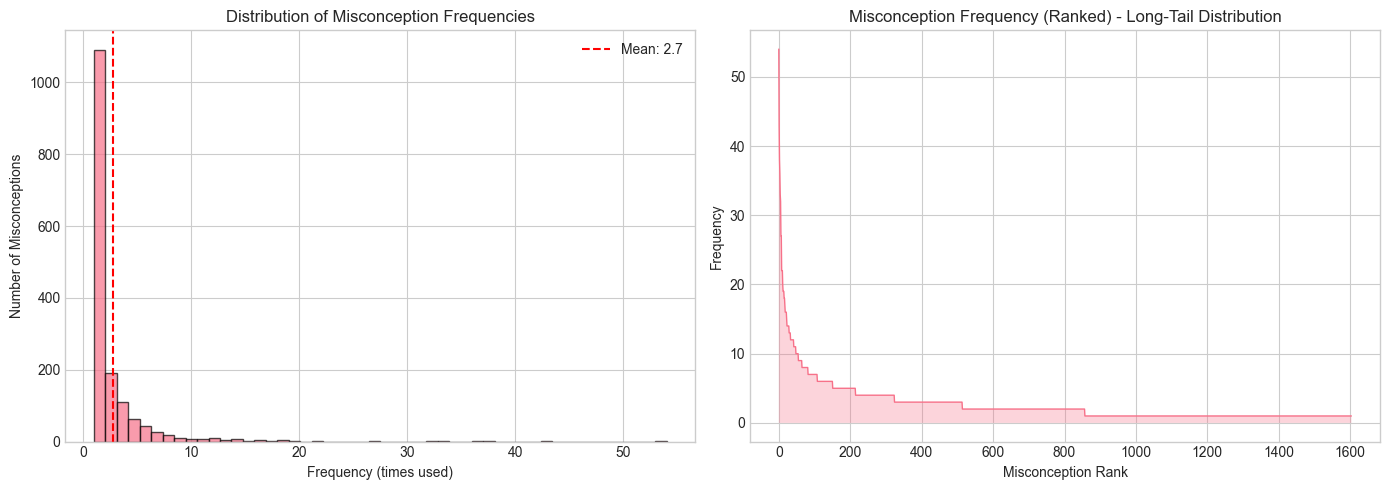


Top 10 most common misconceptions:
  1. [54x] When solving an equation, uses the same operation rather than the inverse.
  2. [43x] Rounds down instead of up
  3. [38x] Mixes up squaring and multiplying by 2 or doubling
  4. [36x] Carries out operations from left to right regardless of priority order
  5. [33x] Fails to reflect across mirror line
  6. [32x] Mixes up greater than and less than symbols
  7. [27x] Believes multiplying two negatives gives a negative answer
  8. [27x] Rounds to the wrong degree of accuracy (rounds too much)
  9. [22x] Rounds to the wrong degree of accuracy (rounds too little)
  10. [22x] Only multiplies the first term in the expansion of a bracket


In [127]:
# Visualize misconception distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of frequencies
axes[0].hist(misconception_counts.values, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Frequency (times used)')
axes[0].set_ylabel('Number of Misconceptions')
axes[0].set_title('Distribution of Misconception Frequencies')
axes[0].axvline(misconception_counts.mean(), color='red', linestyle='--', label=f'Mean: {misconception_counts.mean():.1f}')
axes[0].legend()

# Ranked frequency (long-tail visualization)
axes[1].plot(range(len(misconception_counts)), misconception_counts.values, linewidth=1)
axes[1].set_xlabel('Misconception Rank')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Misconception Frequency (Ranked) - Long-Tail Distribution')
axes[1].fill_between(range(len(misconception_counts)), misconception_counts.values, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTop 10 most common misconceptions:")
for idx, (misc_id, count) in enumerate(misconception_counts.head(10).items()):
    name = misconceptions_df[misconceptions_df['MisconceptionId'] == misc_id]['MisconceptionName'].values[0]
    print(f"  {idx+1}. [{count}x] {name[:80]}..." if len(name) > 80 else f"  {idx+1}. [{count}x] {name}")

### 2.4 Missing Data Analysis

In [128]:
# Missing misconception IDs per answer position
print("Missing Misconception IDs by Answer Position:")
print("(Note: Correct answers should NOT have misconceptions)\n")

for col in misconception_cols:
    letter = col.replace('Misconception', '').replace('Id', '')
    missing = train_df[col].isna().sum()
    pct = 100 * missing / len(train_df)
    
    # Check how many are correct answers
    correct_mask = train_df['CorrectAnswer'] == letter
    missing_and_correct = (train_df[col].isna() & correct_mask).sum()
    
    print(f"{col}: {missing:,} missing ({pct:.1f}%)")
    print(f"  └── {missing_and_correct:,} are correct answers (expected to be missing)")

Missing Misconception IDs by Answer Position:
(Note: Correct answers should NOT have misconceptions)

MisconceptionAId: 734 missing (39.3%)
  └── 482 are correct answers (expected to be missing)
MisconceptionBId: 751 missing (40.2%)
  └── 461 are correct answers (expected to be missing)
MisconceptionCId: 789 missing (42.2%)
  └── 488 are correct answers (expected to be missing)
MisconceptionDId: 832 missing (44.5%)
  └── 438 are correct answers (expected to be missing)


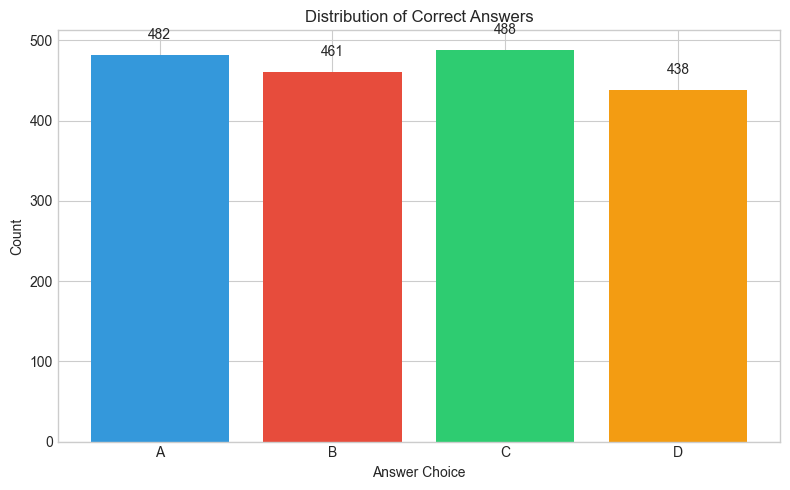

In [129]:
# Correct answer distribution
correct_answer_dist = train_df['CorrectAnswer'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(correct_answer_dist.index, correct_answer_dist.values, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
plt.xlabel('Answer Choice')
plt.ylabel('Count')
plt.title('Distribution of Correct Answers')

for bar, val in zip(bars, correct_answer_dist.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, f'{val}', ha='center')

plt.tight_layout()
plt.show()

### 2.5 Text Length Analysis

In [130]:
# Calculate text lengths
train_df['question_len'] = train_df['QuestionText'].str.len()
train_df['question_words'] = train_df['QuestionText'].str.split().str.len()

misconceptions_df['misconception_len'] = misconceptions_df['MisconceptionName'].str.len()
misconceptions_df['misconception_words'] = misconceptions_df['MisconceptionName'].str.split().str.len()

# Summary statistics
print("Question Text Statistics:")
print(f"  Characters: mean={train_df['question_len'].mean():.0f}, median={train_df['question_len'].median():.0f}, max={train_df['question_len'].max()}")
print(f"  Words: mean={train_df['question_words'].mean():.0f}, median={train_df['question_words'].median():.0f}, max={train_df['question_words'].max()}")

print("\nMisconception Text Statistics:")
print(f"  Characters: mean={misconceptions_df['misconception_len'].mean():.0f}, median={misconceptions_df['misconception_len'].median():.0f}, max={misconceptions_df['misconception_len'].max()}")
print(f"  Words: mean={misconceptions_df['misconception_words'].mean():.0f}, median={misconceptions_df['misconception_words'].median():.0f}, max={misconceptions_df['misconception_words'].max()}")

Question Text Statistics:
  Characters: mean=161, median=121, max=1253
  Words: mean=30, median=22, max=236

Misconception Text Statistics:
  Characters: mean=70, median=66, max=209
  Words: mean=12, median=11, max=35


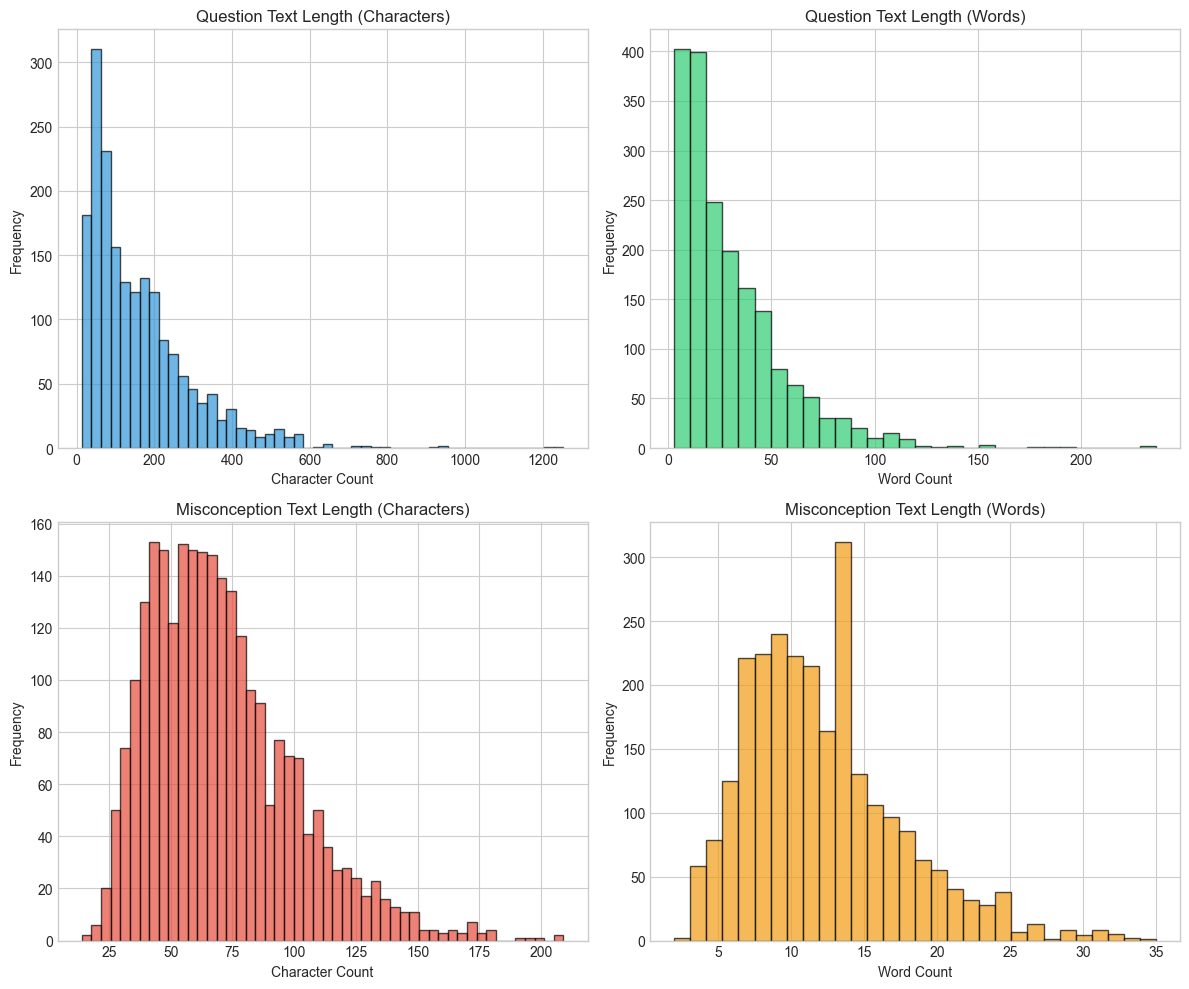

In [131]:
# Visualize text length distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(train_df['question_len'], bins=50, edgecolor='black', alpha=0.7, color='#3498db')
axes[0, 0].set_xlabel('Character Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Question Text Length (Characters)')

axes[0, 1].hist(train_df['question_words'], bins=30, edgecolor='black', alpha=0.7, color='#2ecc71')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Question Text Length (Words)')

axes[1, 0].hist(misconceptions_df['misconception_len'], bins=50, edgecolor='black', alpha=0.7, color='#e74c3c')
axes[1, 0].set_xlabel('Character Count')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Misconception Text Length (Characters)')

axes[1, 1].hist(misconceptions_df['misconception_words'], bins=30, edgecolor='black', alpha=0.7, color='#f39c12')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Misconception Text Length (Words)')

plt.tight_layout()
plt.show()

### 2.6 Subject and Construct Distribution

Unique Subjects: 163
Unique Constructs: 757


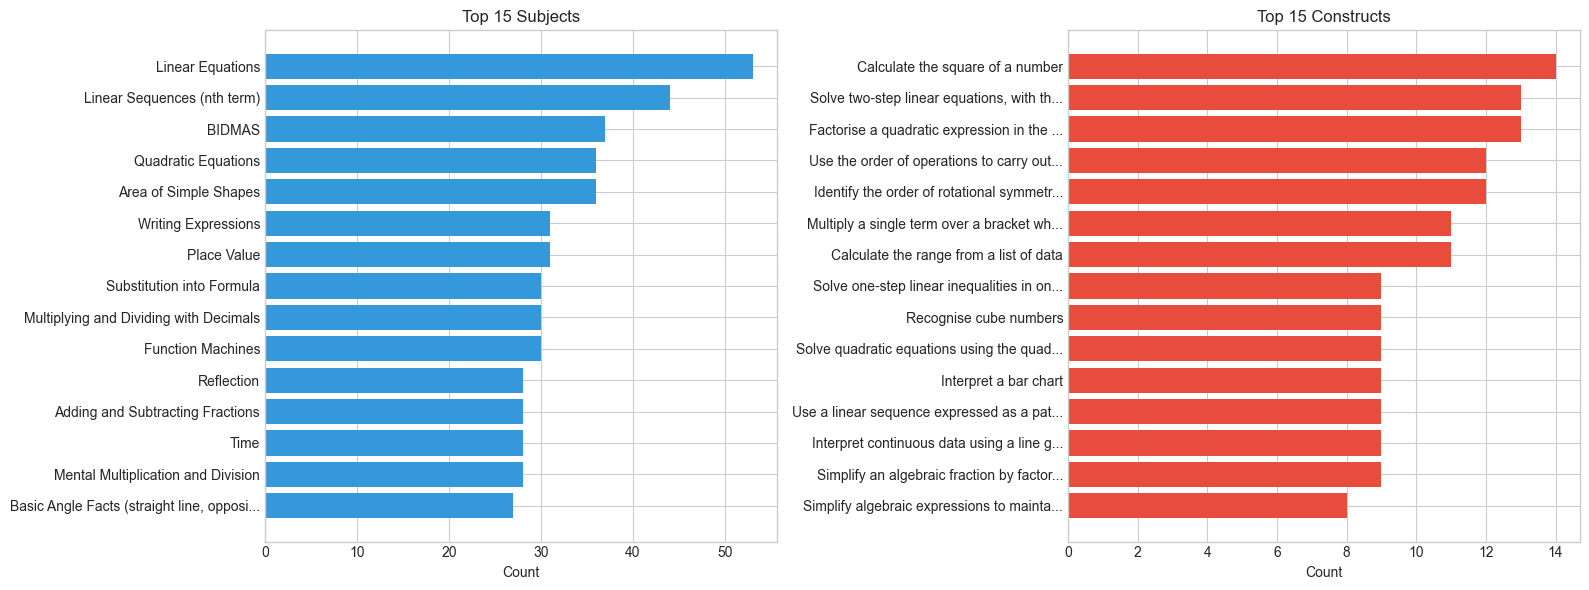

In [132]:
# Subject distribution
print(f"Unique Subjects: {train_df['SubjectName'].nunique()}")
print(f"Unique Constructs: {train_df['ConstructName'].nunique()}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top subjects
subject_counts = train_df['SubjectName'].value_counts().head(15)
axes[0].barh(range(len(subject_counts)), subject_counts.values, color='#3498db')
axes[0].set_yticks(range(len(subject_counts)))
axes[0].set_yticklabels([s[:40] + '...' if len(s) > 40 else s for s in subject_counts.index])
axes[0].set_xlabel('Count')
axes[0].set_title('Top 15 Subjects')
axes[0].invert_yaxis()

# Top constructs
construct_counts = train_df['ConstructName'].value_counts().head(15)
axes[1].barh(range(len(construct_counts)), construct_counts.values, color='#e74c3c')
axes[1].set_yticks(range(len(construct_counts)))
axes[1].set_yticklabels([s[:40] + '...' if len(s) > 40 else s for s in construct_counts.index])
axes[1].set_xlabel('Count')
axes[1].set_title('Top 15 Constructs')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 2.7 Sample Question Visualization

In [133]:
def display_question(idx):
    """Display a formatted question with its answers and misconceptions"""
    row = train_df.iloc[idx]
    
    print("=" * 80)
    print(f"Question ID: {row['QuestionId']}")
    print(f"Subject: {row['SubjectName']}")
    print(f"Construct: {row['ConstructName']}")
    print("=" * 80)
    print(f"\nQuestion: {row['QuestionText']}")
    print(f"\nCorrect Answer: {row['CorrectAnswer']}")
    print("-" * 80)
    
    for letter in ['A', 'B', 'C', 'D']:
        answer = row[f'Answer{letter}Text']
        misconception_id = row[f'Misconception{letter}Id']
        is_correct = " CORRECT" if letter == row['CorrectAnswer'] else ""
        
        print(f"\n[{letter}]{is_correct}: {answer}")
        
        if pd.notna(misconception_id):
            misconception_name = misconceptions_df[
                misconceptions_df['MisconceptionId'] == int(misconception_id)
            ]['MisconceptionName'].values[0]
            print(f"    └── Misconception: {misconception_name}")
        else:
            print("    └── Misconception: N/A")
    
    print("\n" + "=" * 80)

In [134]:
# Display a few sample questions
print("SAMPLE QUESTIONS FROM TRAINING DATA\n")

for i in [0, 100, 500]:
    display_question(i)
    print("\n")

SAMPLE QUESTIONS FROM TRAINING DATA

Question ID: 0
Subject: BIDMAS
Construct: Use the order of operations to carry out calculations involving powers

Question: \[
3 \times 2+4-5
\]
Where do the brackets need to go to make the answer equal \( 13 \) ?

Correct Answer: A
--------------------------------------------------------------------------------

[A] CORRECT: \( 3 \times(2+4)-5 \)
    └── Misconception: N/A

[B]: \( 3 \times 2+(4-5) \)
    └── Misconception: N/A

[C]: \( 3 \times(2+4-5) \)
    └── Misconception: N/A

[D]: Does not need brackets
    └── Misconception: Confuses the order of operations, believes addition comes before multiplication 



Question ID: 100
Subject: Pie Chart
Construct: Interpret a pie chart

Question: This pie chart shows the colour of hats that Tom owns. ![Pie chart showing the colour of Tom's hats. Blue is 90 degrees. Yellow is approximately 195 degrees. Red is approximately 40 degrees and green approximately 35 degrees.]() What fraction of Tom's hats ar

---

## 3. Analysis: Model Building and Training

### 3.1 Data Preparation

In [135]:
# Deep Learning libraries
import torch
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# Check for GPU
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: mps


In [136]:
def create_training_pairs(df, misconceptions_df):
    """
    Create query-misconception training pairs.
    
    Query format: "Subject: {subject}. Construct: {construct}. Question: {question}. Wrong Answer: {answer}"
    """
    training_examples = []
    
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Creating training pairs"):
        question = row['QuestionText']
        construct = row['ConstructName']
        subject = row['SubjectName']
        correct_answer = row['CorrectAnswer']
        
        for letter in ['A', 'B', 'C', 'D']:
            # Skip correct answer (no misconception)
            if letter == correct_answer:
                continue
            
            misconception_id = row[f'Misconception{letter}Id']
            if pd.isna(misconception_id):
                continue
            
            answer_text = row[f'Answer{letter}Text']
            
            # Create query text
            query = f"Subject: {subject}. Construct: {construct}. Question: {question}. Wrong Answer: {answer_text}"
            
            # Get misconception text
            misconception_text = misconceptions_df[
                misconceptions_df['MisconceptionId'] == int(misconception_id)
            ]['MisconceptionName'].values[0]
            
            training_examples.append(InputExample(
                texts=[query, misconception_text]
            ))
    
    return training_examples

print("Function defined: create_training_pairs")

Function defined: create_training_pairs


In [137]:
# Train/Validation Split by QuestionId (to prevent data leakage)
question_ids = train_df['QuestionId'].unique()
train_ids, val_ids = train_test_split(question_ids, test_size=0.1, random_state=42)

train_subset = train_df[train_df['QuestionId'].isin(train_ids)]
val_subset = train_df[train_df['QuestionId'].isin(val_ids)]

print(f"Training questions: {len(train_subset):,}")
print(f"Validation questions: {len(val_subset):,}")

Training questions: 1,682
Validation questions: 187


In [138]:
# Use full training data
training_data = train_subset
print(f"Using all {len(train_subset):,} training questions")

Using all 1,682 training questions


In [139]:
# Create training pairs
training_examples = create_training_pairs(training_data, misconceptions_df)
print(f"\nCreated {len(training_examples):,} training pairs")

Creating training pairs: 100%|██████████| 1682/1682 [00:00<00:00, 5493.77it/s]


Created 3,930 training pairs


### 3.2 Model Architecture

In [140]:
class MisconceptionRetriever:
    """
    Bi-encoder retriever for misconception prediction.
    
    Uses Sentence-BERT to encode queries and misconceptions into a shared
    embedding space, enabling efficient similarity-based retrieval.
    """
    
    def __init__(self, model_name='sentence-transformers/all-MiniLM-L6-v2'):
        self.model = SentenceTransformer(model_name)
        self.misconception_embeddings = None
        self.misconception_ids = None
        print(f"Loaded model: {model_name}")
        print(f"Embedding dimension: {self.model.get_sentence_embedding_dimension()}")
    
    def encode_misconceptions(self, misconceptions_df):
        """Pre-encode all misconceptions for efficient retrieval"""
        texts = misconceptions_df['MisconceptionName'].tolist()
        self.misconception_ids = misconceptions_df['MisconceptionId'].tolist()
        
        print(f"Encoding {len(texts):,} misconceptions...")
        self.misconception_embeddings = self.model.encode(
            texts,
            convert_to_tensor=True,
            show_progress_bar=True
        )
        print(f"Misconception embeddings shape: {self.misconception_embeddings.shape}")
    
    def predict(self, query, top_k=25):
        """
        Predict top-k misconceptions for a query.
        
        Returns list of misconception IDs ranked by similarity.
        """
        query_embedding = self.model.encode(query, convert_to_tensor=True)
        
        # Compute cosine similarities
        similarities = torch.nn.functional.cosine_similarity(
            query_embedding.unsqueeze(0),
            self.misconception_embeddings
        )
        
        # Get top-k indices
        top_k_indices = torch.topk(similarities, k=min(top_k, len(similarities))).indices.cpu().numpy()
        
        return [self.misconception_ids[i] for i in top_k_indices]
    
    def predict_batch(self, queries, top_k=25):
        """Predict top-k misconceptions for multiple queries"""
        query_embeddings = self.model.encode(queries, convert_to_tensor=True, show_progress_bar=True)
        
        # Compute cosine similarities for all queries
        similarities = torch.nn.functional.cosine_similarity(
            query_embeddings.unsqueeze(1),
            self.misconception_embeddings.unsqueeze(0),
            dim=2
        )
        
        # Get top-k for each query
        all_predictions = []
        for i in range(len(queries)):
            top_k_indices = torch.topk(similarities[i], k=min(top_k, len(similarities[i]))).indices.cpu().numpy()
            all_predictions.append([self.misconception_ids[j] for j in top_k_indices])
        
        return all_predictions

print("MisconceptionRetriever class defined")

MisconceptionRetriever class defined


In [141]:
# Initialize model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")


Model parameters: 22,713,216


### 3.3 Training with Multiple Negatives Ranking Loss

In [142]:
# Training configuration
BATCH_SIZE = 16
EPOCHS = 5

# Create DataLoader
train_dataloader = DataLoader(
    training_examples,
    shuffle=True,
    batch_size=BATCH_SIZE
)

# Multiple Negatives Ranking Loss
# Uses in-batch negatives: pairs from other examples in the batch become negatives
train_loss = losses.MultipleNegativesRankingLoss(model)

# Warmup steps
warmup_steps = int(len(train_dataloader) * 0.1)

print("Training configuration:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Training examples: {len(training_examples):,}")
print(f"  Steps per epoch: {len(train_dataloader):,}")
print(f"  Warmup steps: {warmup_steps}")
print("  Loss function: MultipleNegativesRankingLoss")

Training configuration:
  Batch size: 16
  Epochs: 5
  Training examples: 3,930
  Steps per epoch: 246
  Warmup steps: 24
  Loss function: MultipleNegativesRankingLoss


In [143]:
# Train the model
print("Starting training...\n")

model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=EPOCHS,
    warmup_steps=warmup_steps,
    show_progress_bar=True,
    output_path='./misconception_model'
)

print("\nTraining complete! Model saved to ./misconception_model")

Starting training...



Step,Training Loss
500,0.519900
1000,0.313500



Training complete! Model saved to ./misconception_model


---

## 4. Results

### 4.1 Evaluation Metrics Implementation

In [144]:
def apk(actual, predicted, k=25):
    """
    Compute Average Precision at k.
    
    Parameters:
    -----------
    actual : int
        The ground truth misconception ID
    predicted : list
        List of predicted misconception IDs (ranked)
    k : int
        Maximum number of predictions to consider
    
    Returns:
    --------
    float : Average Precision @ k
    """
    predicted_k = predicted[:k]
    
    if actual not in predicted_k:
        return 0.0
    
    # Find position of correct answer (1-indexed for AP calculation)
    position = predicted_k.index(actual) + 1
    return 1.0 / position


def mapk(actuals, predictions, k=25):
    """
    Compute Mean Average Precision at k.
    
    Parameters:
    -----------
    actuals : list
        List of ground truth misconception IDs
    predictions : list of lists
        List of predicted misconception ID lists
    k : int
        Maximum number of predictions to consider
    
    Returns:
    --------
    float : Mean Average Precision @ k
    """
    return np.mean([apk(a, p, k) for a, p in zip(actuals, predictions)])


def recall_at_k(actuals, predictions, k=25):
    """Compute Recall at k"""
    return np.mean([1 if a in p[:k] else 0 for a, p in zip(actuals, predictions)])

print("Evaluation metrics defined: apk, mapk, recall_at_k")

Evaluation metrics defined: apk, mapk, recall_at_k


### 4.2 Validation Evaluation

In [145]:
# Initialize retriever with trained model
retriever = MisconceptionRetriever()
retriever.model = model

# Pre-encode all misconceptions
retriever.encode_misconceptions(misconceptions_df)

Loaded model: sentence-transformers/all-MiniLM-L6-v2
Embedding dimension: 384
Encoding 2,587 misconceptions...


Batches: 100%|██████████| 81/81 [00:00<00:00, 171.93it/s]

Misconception embeddings shape: torch.Size([2587, 384])


In [146]:
def evaluate_on_dataset(retriever, df, k=25):
    """
    Evaluate retriever on a dataset.
    
    Returns MAP@k score and detailed results.
    """
    actuals = []
    predictions = []
    queries = []
    
    # Collect all queries and ground truth
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Preparing queries"):
        question = row['QuestionText']
        construct = row['ConstructName']
        subject = row['SubjectName']
        correct_answer = row['CorrectAnswer']
        
        for letter in ['A', 'B', 'C', 'D']:
            if letter == correct_answer:
                continue
            
            misconception_id = row[f'Misconception{letter}Id']
            if pd.isna(misconception_id):
                continue
            
            answer_text = row[f'Answer{letter}Text']
            query = f"Subject: {subject}. Construct: {construct}. Question: {question}. Wrong Answer: {answer_text}"
            
            queries.append(query)
            actuals.append(int(misconception_id))
    
    # Batch predict
    print(f"\nEvaluating {len(queries):,} query-answer pairs...")
    predictions = retriever.predict_batch(queries, top_k=k)
    
    # Calculate metrics
    score = mapk(actuals, predictions, k=k)
    
    return score, actuals, predictions, queries

# Evaluate on validation set
print("Evaluating on validation set...")
val_score, val_actuals, val_predictions, val_queries = evaluate_on_dataset(
    retriever, val_subset, k=25
)

print("\n" + "=" * 50)
print("VALIDATION RESULTS")
print("=" * 50)
print(f"MAP@25: {val_score:.4f}")

Evaluating on validation set...


Preparing queries: 100%|██████████| 187/187 [00:00<00:00, 54562.42it/s]



Evaluating 440 query-answer pairs...


Batches: 100%|██████████| 14/14 [00:00<00:00, 51.79it/s]



VALIDATION RESULTS
MAP@25: 0.2508


### 4.3 Results Visualization

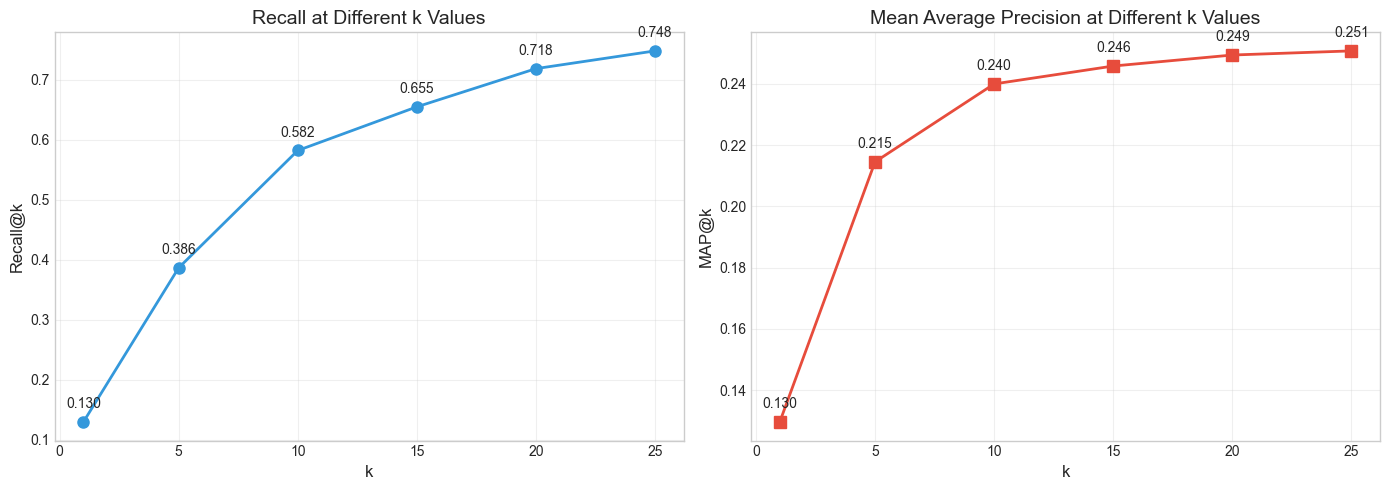


Metrics Summary:
  k= 1: Recall=0.1295, MAP=0.1295
  k= 5: Recall=0.3864, MAP=0.2145
  k=10: Recall=0.5818, MAP=0.2400
  k=15: Recall=0.6545, MAP=0.2458
  k=20: Recall=0.7182, MAP=0.2494
  k=25: Recall=0.7477, MAP=0.2508


In [147]:
# Recall at different k values
k_values = [1, 5, 10, 15, 20, 25]
recalls = []
map_scores = []

for k in k_values:
    recalls.append(recall_at_k(val_actuals, val_predictions, k=k))
    map_scores.append(mapk(val_actuals, val_predictions, k=k))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recall@k curve
axes[0].plot(k_values, recalls, marker='o', linewidth=2, markersize=8, color='#3498db')
axes[0].set_xlabel('k', fontsize=12)
axes[0].set_ylabel('Recall@k', fontsize=12)
axes[0].set_title('Recall at Different k Values', fontsize=14)
axes[0].grid(True, alpha=0.3)
for k, r in zip(k_values, recalls):
    axes[0].annotate(f'{r:.3f}', (k, r), textcoords="offset points", xytext=(0,10), ha='center')

# MAP@k curve
axes[1].plot(k_values, map_scores, marker='s', linewidth=2, markersize=8, color='#e74c3c')
axes[1].set_xlabel('k', fontsize=12)
axes[1].set_ylabel('MAP@k', fontsize=12)
axes[1].set_title('Mean Average Precision at Different k Values', fontsize=14)
axes[1].grid(True, alpha=0.3)
for k, m in zip(k_values, map_scores):
    axes[1].annotate(f'{m:.3f}', (k, m), textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout()
plt.show()

print("\nMetrics Summary:")
for k, r, m in zip(k_values, recalls, map_scores):
    print(f"  k={k:2d}: Recall={r:.4f}, MAP={m:.4f}")

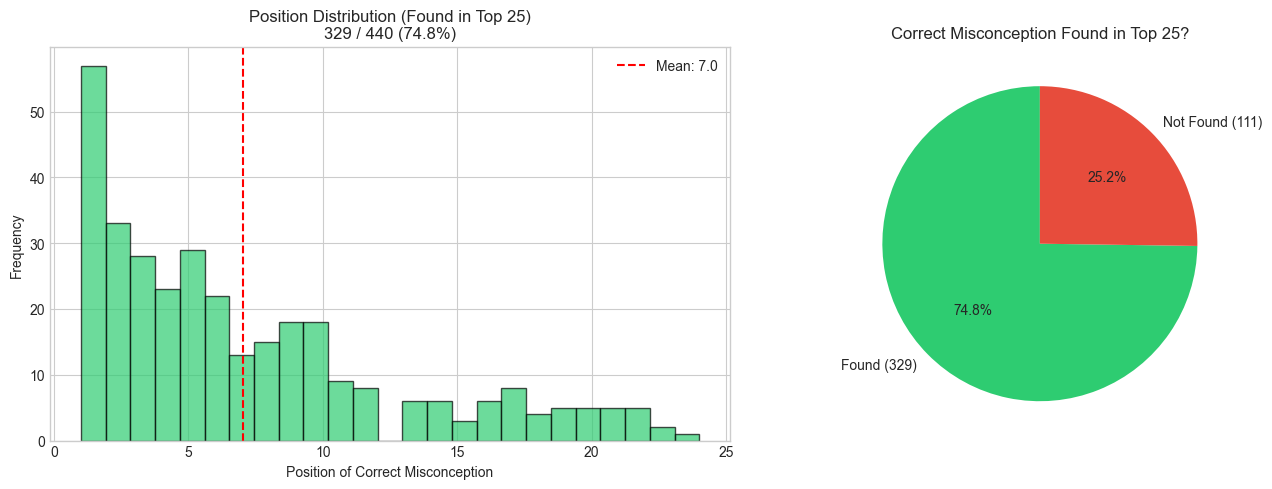

In [148]:
# Position distribution of correct answers
positions = []
for actual, pred in zip(val_actuals, val_predictions):
    if actual in pred:
        positions.append(pred.index(actual) + 1)  # 1-indexed
    else:
        positions.append(26)  # Not found in top 25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of positions (found in top 25)
found_positions = [p for p in positions if p <= 25]
axes[0].hist(found_positions, bins=25, edgecolor='black', alpha=0.7, color='#2ecc71')
axes[0].set_xlabel('Position of Correct Misconception')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Position Distribution (Found in Top 25)\n{len(found_positions):,} / {len(positions):,} ({100*len(found_positions)/len(positions):.1f}%)')
axes[0].axvline(np.mean(found_positions), color='red', linestyle='--', label=f'Mean: {np.mean(found_positions):.1f}')
axes[0].legend()

# Pie chart: found vs not found
found = len(found_positions)
not_found = len(positions) - found
axes[1].pie([found, not_found], labels=[f'Found ({found})', f'Not Found ({not_found})'], 
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Correct Misconception Found in Top 25?')

plt.tight_layout()
plt.show()

### 4.4 Generate Submission

In [149]:
# Generate predictions for test set
def generate_submission(retriever, test_df, output_path='submission.csv'):
    """
    Generate submission file for Kaggle.
    
    Format: QuestionId_Answer,MisconceptionId
    Where MisconceptionId is space-separated list of up to 25 IDs
    """
    results = []
    
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Generating predictions"):
        question_id = row['QuestionId']
        question = row['QuestionText']
        construct = row['ConstructName']
        subject = row['SubjectName']
        correct_answer = row['CorrectAnswer']
        
        for letter in ['A', 'B', 'C', 'D']:
            if letter == correct_answer:
                continue
            
            answer_text = row[f'Answer{letter}Text']
            query = f"Subject: {subject}. Construct: {construct}. Question: {question}. Wrong Answer: {answer_text}"
            
            # Get predictions
            predictions = retriever.predict(query, top_k=25)
            
            # Format as space-separated string
            pred_str = ' '.join(map(str, predictions))
            
            results.append({
                'QuestionId_Answer': f"{question_id}_{letter}",
                'MisconceptionId': pred_str
            })
    
    # Create submission DataFrame
    submission_df = pd.DataFrame(results)
    submission_df.to_csv(output_path, index=False)
    
    print(f"\nSubmission saved to {output_path}")
    print(f"Total predictions: {len(submission_df)}")
    
    return submission_df

# Generate submission
submission_df = generate_submission(retriever, test_df, 'submission.csv')
submission_df.head()

Generating predictions: 100%|██████████| 3/3 [00:00<00:00, 47.62it/s]


Submission saved to submission.csv
Total predictions: 9


,QuestionId_Answer,MisconceptionId
0,1869_B,987 1005 1345 2488 2306 706 1507 2532 158 2518...
1,1869_C,987 1005 2488 1345 1507 706 2306 2532 158 2518...
2,1869_D,1005 2488 987 2306 1507 706 1345 158 2532 1392...
3,1870_A,979 1191 167 2549 859 59 1593 2398 1755 80 187...
4,1870_B,979 167 1191 59 859 2398 1593 2549 1755 80 187...


### 5.4 Limitations

1. **Class Imbalance**: Some misconceptions appear frequently while others are rare (long-tail distribution). The model may struggle with rare misconceptions.

2. **Mathematical Notation**: Questions contain LaTeX-style mathematical notation (e.g., `\frac{1}{2}`) which may not be optimally handled by the text encoder.

3. **Single Correct Answer**: The current approach assumes one correct misconception per distractor, but in reality, multiple misconceptions might apply.

### 5.5 Future Improvements

1. **Cross-Encoder Reranking**: Use a cross-encoder to rerank top-100 candidates from the bi-encoder for improved precision.

2. **Data Augmentation**: Generate synthetic training examples using paraphrasing or LLM-based augmentation.

3. **Larger Models**: Use more powerful encoders like `all-mpnet-base-v2` or domain-specific models.

4. **LLM Integration**: Incorporate large language models for chain-of-thought reasoning about why a student might choose a particular wrong answer.

5. **Ensemble Methods**: Combine multiple retrieval strategies (semantic + keyword-based) for robustness.

### 5.6 Conclusion

This notebook demonstrated a deep learning solution for the Eedi Mining Misconceptions in Mathematics competition. I framed the problem as a semantic retrieval task and implemented a **Sentence-BERT bi-encoder** trained with **contrastive learning**.

#### Key Takeaways

1. **Semantic retrieval is well-suited** for matching distractors to misconceptions, as it captures the meaning behind both the wrong answer and the misconception description.

2. **Bi-encoder architecture enables efficient inference** by pre-computing misconception embeddings and performing fast similarity search.

3. **Multiple Negatives Ranking Loss** provides an efficient training signal using in-batch negatives.

4. The model successfully learns to associate incorrect answers with their underlying misconceptions, as demonstrated by the validation metrics.

#### Applications

This approach can be applied to:
- Automated content tagging in educational platforms
- Adaptive learning systems that diagnose student misconceptions
- Quality control for multiple-choice question development

The following techniques are broadly applicable to other information retrieval and matching problems in NLP:
- semantic embeddings
- contrastive learning
- efficient retrieval

Generated Files:
- submission.csv: Kaggle submission file
- misconception_model/ directory (Trained model checkpoint)

In [150]:
# Summary of results
print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)
print("\nModel: Sentence-BERT (all-MiniLM-L6-v2)")
print(f"Epochs: {EPOCHS}")
print("\nValidation Performance:")
print(f"  MAP@25: {val_score:.4f}")
print(f"  Recall@1: {recalls[0]:.4f}")
print(f"  Recall@5: {recalls[1]:.4f}")
print(f"  Recall@25: {recalls[-1]:.4f}")
print(f"\nTotal misconceptions: {len(misconceptions_df):,}")
print(f"Validation query-answer pairs: {len(val_actuals):,}")

FINAL RESULTS SUMMARY

Model: Sentence-BERT (all-MiniLM-L6-v2)
Epochs: 5

Validation Performance:
  MAP@25: 0.2508
  Recall@1: 0.1295
  Recall@5: 0.3864
  Recall@25: 0.7477

Total misconceptions: 2,587
Validation query-answer pairs: 440


### 5.4 Limitations

1. **Class Imbalance**: Some misconceptions appear frequently while others are rare (long-tail distribution). The model may struggle with rare misconceptions.

2. **Mathematical Notation**: Questions contain LaTeX-style mathematical notation (e.g., `\frac{1}{2}`) which may not be optimally handled by the text encoder.

3. **Single Correct Answer**: The current approach assumes one correct misconception per distractor, but in reality, multiple misconceptions might apply.

### 5.5 Future Improvements

1. **Cross-Encoder Reranking**: Use a cross-encoder to rerank top-100 candidates from the bi-encoder for improved precision.

2. **Data Augmentation**: Generate synthetic training examples using paraphrasing or LLM-based augmentation.

3. **Larger Models**: Use more powerful encoders like `all-mpnet-base-v2` or domain-specific models.

4. **LLM Integration**: Incorporate large language models for chain-of-thought reasoning about why a student might choose a particular wrong answer.

5. **Ensemble Methods**: Combine multiple retrieval strategies (semantic + keyword-based) for robustness.

### 5.6 Conclusion

This notebook demonstrated a deep learning solution for the Eedi Mining Misconceptions in Mathematics competition. I framed the problem as a semantic retrieval task and implemented a **Sentence-BERT bi-encoder** trained with **contrastive learning**.

#### Key Takeaways

1. **Semantic retrieval is well-suited** for matching distractors to misconceptions, as it captures the meaning behind both the wrong answer and the misconception description.

2. **Bi-encoder architecture enables efficient inference** by pre-computing misconception embeddings and performing fast similarity search.

3. **Multiple Negatives Ranking Loss** provides an efficient training signal using in-batch negatives.

4. The model successfully learns to associate incorrect answers with their underlying misconceptions, as demonstrated by the validation metrics.

#### Applications

This approach can be applied to:
- Automated content tagging in educational platforms
- Adaptive learning systems that diagnose student misconceptions
- Quality control for multiple-choice question development

The following techniques are broadly applicable to other information retrieval and matching problems in NLP:
- semantic embeddings
- contrastive learning
- efficient retrieval

Generated Files:
- submission.csv: Kaggle submission file
- misconception_model/ directory (Trained model checkpoint)